<div align="center" style="direction: ltr; font-family: monospace;">

| | |
|:--|:--|
| **University** | Ferdowsi University of Mashhad |
| **Course** | Applied Linear Algebra |
| **Instructor** | Dr. Rouhani |
| **Lab** | FUM Linear Algebra lab 03 |
| **Semester** | Spring 2026 |
| **Teaching Assistant** | Arman Bijari |
| **Telegram** | [t.me/Arman_Bjr](https://t.me/Arman_Bjr) |
| **Deadline** | 22 Khordad 1405 |

</div>

---

> **Grading note.**
> The final mark for this lab is determined entirely by your **ارائه** (oral presentation).
> Submitting the notebook is required for eligibility, but the deliverable itself carries no
> direct weight. You are expected to understand and be able to explain the code
> and every mathematical step in your submission.

---

# Coreset Selection and Anomaly Detection

## A Linear Algebra Perspective

***

### Introduction

A factory that produces glass bottles must catch defective ones: cracks, contamination,
broken pieces. One practical approach is to train a system that memorises the appearance
of good bottles and flags anything that looks too different.

The system works by comparing local regions of a new bottle image to a large collection
of patches extracted from normal training images. Each patch is represented as a vector
in a high-dimensional feature space. If the nearest match in the collection is too far
away, the patch is flagged as anomalous.

The collection of stored patch vectors is called the **memory bank**. For the bottle
category of the MVTec dataset, the full memory bank contains roughly 62 000 vectors of
dimension 768. Storing and searching this bank at inference time is expensive.

The question is: can we keep a small subset of these vectors and still detect anomalies
reliably? This is the **coreset selection** problem.

The central observation of this lab is that the right measure of importance for each
row of a matrix is already encoded in its **leverage score**, the diagonal entry of the
hat matrix. Leverage scores arise naturally from the singular value decomposition and
give a principled, geometry-aware way to choose which rows to keep.

**What you will do:**
- Derive the hat matrix from the normal equations and prove its key properties
- Show that leverage scores are the squared row norms of the left singular matrix
- Implement a coreset sampler based on leverage scores
- Apply it to real patch features from the MVTec bottle dataset
- Measure how detection quality changes as the coreset shrinks

**Prerequisites:** NumPy, Matplotlib, and the scikit-learn `randomized_svd` utility.
No neural networks or deep learning frameworks are needed.

***

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.utils.extmath import randomized_svd
import os
import urllib.request
import zipfile

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

---
## Background

Before the linear algebra starts, this section builds the vocabulary.
Read it carefully. Every term introduced here appears in the exercises.

***
### The Task: Industrial Anomaly Detection

The **MVTec Anomaly Detection** dataset contains high-resolution photographs of
industrial objects and textures recorded under controlled lighting.
For the bottle category, training images show only normal, defect-free bottles.
Test images contain both normal bottles and bottles with three types of defect:
broken large, broken small, and contamination.

The goal is to build a system that, given a new bottle image, outputs a score
indicating how likely it is to contain a defect.
The system is trained on normal images only. It has never seen a defect.

![MVTec Anomaly Detection dataset samples](https://www.mvtec.com/fileadmin/_processed_/0/4/csm_teaser_image_dataset_anomaly_detection_b7de33b91e.webp)

*Figure: Sample categories from the MVTec AD dataset.
The bottle category is one of fifteen object and texture classes.*

***
### What Is a Patch?

A digital image is a rectangular grid of pixels. For a colour image of size
$H \times W$, each pixel carries three numbers (red, green, blue intensity).

A **patch** is a small rectangular sub-region of the image.
If we slide a window of size $p \times p$ across the image with stride $s$,
we obtain a grid of $(H/s) \times (W/s)$ non-overlapping patches.
Each patch covers a local neighbourhood of pixels.

In this lab, the backbone network divides each bottle image into a
**56 x 56 grid of patches**, giving 3 136 patches per image.
Each patch covers roughly the same physical area on the bottle surface.

![Image divided into patches for the Vision Transformer](https://upload.wikimedia.org/wikipedia/commons/thumb/9/93/Vision_Transformer.png/250px-Vision_Transformer.png)

*Figure: An image divided into a regular grid of patches.
Each coloured square is one patch.
The same principle applies here: every bottle image is divided into 3 136 patches
arranged in a 56 x 56 grid.*

***
### Feature Extraction

A raw patch is a block of pixel values. Pixel values are not a useful
representation for comparing patches because two patches of the same bottle
region taken under slightly different lighting will have very different pixel
values but should be considered similar.

A **feature extractor** (here, a ResNet-50 convolutional network pre-trained
on ImageNet) maps each patch to a vector in $\mathbb{R}^d$.
This vector encodes what the patch looks like in a way that is more stable
to changes in brightness, contrast, and small deformations.

In this lab, $d = 768$. Each patch becomes a single vector of 768 numbers.
Two patches that look similar will have similar feature vectors.
Two patches that look different (for instance, a smooth glass surface versus
a crack) will have feature vectors that are far apart in $\mathbb{R}^{768}$.

![A typical convolutional neural network architecture](https://upload.wikimedia.org/wikipedia/commons/thumb/6/63/Typical_cnn.png/500px-Typical_cnn.png)

*Figure: A convolutional neural network processes an image through multiple layers.
The output of an intermediate layer, evaluated at a spatial position,
is the feature vector for the patch centred at that position.*

***
### The Memory Bank

During training we process every normal bottle image.
For each image we extract 3 136 feature vectors, one per patch.
We concatenate all of them into a single matrix

$$M \in \mathbb{R}^{N \times d}$$

where $N$ is the total number of patches across all training images and
$d = 768$ is the feature dimension.
With 20 training images, $N = 20 \times 3136 = 62\,720$.

Each row of $M$ is a feature vector for one patch from one normal training image.
Together, these rows define what a normal bottle patch looks like.
This matrix is called the **memory bank**.

***
### Nearest-Neighbor Anomaly Scoring

At test time, take a new bottle image and extract its 3 136 patch feature vectors.
For each test patch $q \in \mathbb{R}^{768}$, compute its distance to the
nearest row in the memory bank:

$$s(q) = \min_{m \in M} \|q - m\|_2$$

If $s(q)$ is large, the test patch looks unlike any normal patch.
It is likely anomalous.
The image-level score is the maximum patch score over all patches.

This approach is effective but expensive: searching through 62 720 rows for
each of 3 136 test patches at inference time costs $O(N \cdot d)$ per patch.
If $N$ is reduced by selecting a small coreset $C \subset M$ with
$|C| = m \ll N$, inference becomes $O(m \cdot d)$, much faster.

**The question is: which $m$ rows should we keep?**
This is where linear algebra enters.

***

***
## Data

The features in this lab come from the **MVTec Anomaly Detection** dataset,
bottle category. The original images are available at:
> https://www.kaggle.com/datasets/thtuan/mvtecad-mvtec-anomaly-detection

The patch features used here were precomputed from a wide ResNet-50 backbone
and are provided separately as NumPy arrays so that no GPU or deep learning
framework is required.

**normal/** contains 20 files, one per training image.
Each file has shape (768, 56, 56): 768 feature channels over a 56 x 56 spatial
grid of patches (3 136 patches per image).

**anomaly/** contains pairs of files per test image.
For an image named `broken_large_000`, the file `broken_large_000_anomaly.npy`
holds feature vectors of patches inside the defect region (shape: N x 768),
and `broken_large_000_normal.npy` holds background patches (shape: M x 768).
Every test image satisfies N + M = 3 136.

There are three defect types: **broken large**, **broken small**, and **contamination**.

Set `DATA_DIR` to your local data path, or set `DATA_URL` to the link provided
by your instructor to download the precomputed features automatically.

In [4]:
# ---- configuration: set one of these ----
DATA_DIR = r"D:\ehsan\university\term4\linear_algebra\programing_projects\last_project\Data"   # e.g. r'C:\Users\you\Data'  or  '/home/you/Data'
DATA_URL = "https://www.kaggle.com/datasets/thtuan/mvtecad-mvtec-anomaly-detection"   # download link provided by your instructor


def get_data_dir(local=None, url=None):
    if local and os.path.isdir(local):
        return local
    if url:
        print('downloading data ...')
        urllib.request.urlretrieve(url, 'data.zip')
        with zipfile.ZipFile('data.zip') as zf:
            zf.extractall('.')
        os.remove('data.zip')
        return 'Data'
    raise RuntimeError(
        'Set DATA_DIR to your local data path '
        'or DATA_URL to the download link provided by your instructor.'
    )


data_dir = get_data_dir(DATA_DIR, DATA_URL)
print('data directory:', data_dir)


data directory: D:\ehsan\university\term4\linear_algebra\programing_projects\last_project\Data


In [56]:
normal_dir  = os.path.join(data_dir, 'normal')
anomaly_dir = os.path.join(data_dir, 'anomaly')
normal_files = sorted(os.listdir(normal_dir))

patches_list = []
for fname in normal_files: # this loop iterates per image numbers 
    features = np.load(os.path.join(normal_dir, fname))  # (768, 56, 56)
    C, H, W = features.shape
    patches = features.reshape(C, H * W).T               # (3136, 768)
    patches_list.append(patches)

memory_bank = np.concatenate(patches_list, axis=0).astype(np.float32)  # (62720, 768)
print('memory bank shape:', memory_bank.shape)
print('feature dimension:', memory_bank.shape[1])
print('total patches:', memory_bank.shape[0])



memory bank shape: (62720, 768)
feature dimension: 768
total patches: 62720


---
## Section 1. The Hat Matrix

Let $A \in \mathbb{R}^{n \times d}$ with $n > d$ and $\text{rank}(A) = d$.
The least squares problem $\min_x \|Ax - b\|_2$ has the unique solution

$$x^* = (A^T A)^{-1} A^T b$$

and the fitted values are

$$\hat{b} = A x^* = A (A^T A)^{-1} A^T b = H b$$

where $H = A(A^T A)^{-1} A^T$ is the **hat matrix** (also called the projection matrix).

The diagonal entry $h_{ii}$ is the **leverage score** of the $i$-th observation.
It measures how much observation $i$ influences its own fitted value.

**Properties of $H$:**
1. $H$ is symmetric: $H^T = H$
2. $H$ is idempotent: $H^2 = H$
3. $\text{tr}(H) = \text{rank}(A)$
4. $0 \le h_{ii} \le 1$ for all $i$

These four properties follow directly from the definition.
Properties 3 and 4 together imply that the leverage scores sum to $d$.

In [ ]:
rng = np.random.default_rng(0)
n, d = 50, 8
A = rng.standard_normal((n, d))


def hat_matrix(A):
    """Return the hat matrix H = A (A^T A)^{-1} A^T."""
    # TODO
    # Use np.linalg.solve to compute (A^T A)^{-1} A^T. Do not use np.linalg.inv.
    # Hint: if Bx = C has solution x = B^{-1} C, relate this to the formula for H.
    H = A @ np.linalg.solve(A.T@A,A.T)
    return H


H = hat_matrix(A)

# verify the four properties; fill in the correct tolerance for atol
print('symmetric:  ', np.allclose(H, H.T, atol=1e-6))
print('idempotent: ', np.allclose(H @ H, H, atol=1e-6))
print('trace(H):   ', np.trace(H))
print('rank(A):    ', np.linalg.matrix_rank(A))
# Question: trace(H) should equal rank(A). Is your result exact? yes , alomost(real value is 7.999999999999999)
# Explain in a markdown cell why floating point prevents exact equality here.

symmetric:   True
idempotent:  True
trace(H):    7.999999999999999
rank(A):     8


### my answer related to the question above : 
* the answer in my own opiniion is : related that what we learned in computer architecture , there 's a gap in our real mathemtics and how the machines(computers ) work. that is in how floating point numbers are intract in computers and calculate , i mean for example it's ok to say in progreamming a = 0.2 + 0.25 and there is no bug for that because they can represent exacly using binary form , but how about such float numbers like 0.1 ? as you can imagine the is no explicite represenation of this number in binary form , so here related that i said we encouter to such numbers between 0 and 1 , so they may not save to storage accuratly , so the precition of our calcualtion of trace of matric A that is sum of diognal elements get's a little bit wrong

the min value of our diagnal values is : 0.01401078684357625
the maximun value for our diagnal values is : 0.36755743886851033
the sum value for all diagnal values is : 7.999999999999999


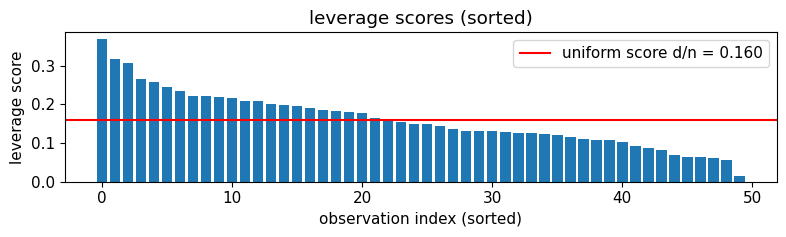

the number of observations that have higher leverage score above unifrom baseline is 23


In [25]:
leverage_scores = np.diag(H)

# TODO: verify that all leverage scores lie in [0, 1] and that they sum to rank(A)
# print the min, max, and sum
if not np.all((leverage_scores >= 0) & (leverage_scores <= 1)):
    raise ValueError("Not all leverage scores are in [0, 1]") # if an error raised , so there is an diagnal element that is greater then one or less and zero.


print(f"the min value of our diagnal values is : {np.min(leverage_scores)}")
print(f"the maximun value for our diagnal values is : {np.max(leverage_scores)}")
print(f"the sum value for all diagnal values is : {np.sum(leverage_scores)}") # as it clear in terminal and what we talk above the sum(trace) is near rank of matrix.



plt.figure(figsize=(8, 2.5))
plt.bar(range(n), np.sort(leverage_scores)[::-1])
plt.axhline(d / n, color='red', lw=1.5, label=f'uniform score d/n = {d/n:.3f}')
plt.xlabel('observation index (sorted)')
plt.ylabel('leverage score')
plt.title('leverage scores (sorted)')
plt.legend()
plt.tight_layout()
plt.show()
# # Question: how many observations have leverage score above the uniform baseline?
print(f"the number of observations that have higher leverage score above unifrom baseline is {np.sum(leverage_scores > d/n)}")
# as we see in output there is 23 observations.
# # What does it mean geometrically for a row to have a high leverage score?


### answer of the last qeustion related to above cell 
* A row with high leverage score corresponds to a data point that lies in an extreme region of the feature space and has a strong influence on the regression fit. Geometrically, such points are far from the bulk of the data and have a large projection onto the column space of A, meaning they strongly affect the shape of the fitted model.


***
## Section 2. Leverage Scores via the SVD

Computing $H = A(A^T A)^{-1} A^T$ directly costs $O(n d^2 + n^2)$ and requires
storing an $n \times n$ matrix. For $n = 62\,720$ this is impractical.

The thin SVD gives a better route. Write $A = U \Sigma V^T$ where
$U \in \mathbb{R}^{n \times d}$, $\Sigma \in \mathbb{R}^{d \times d}$,
$V \in \mathbb{R}^{d \times d}$, and $U^T U = I$.

**Claim:** $H = U U^T$.

*Proof.*
$$H = A(A^T A)^{-1} A^T = U\Sigma V^T (V \Sigma^2 V^T)^{-1} V \Sigma U^T
= U \Sigma V^T V \Sigma^{-2} V^T V \Sigma U^T = U U^T. \quad \square$$

Therefore
$$h_{ii} = \|u_i\|_2^2$$
where $u_i^T$ is the $i$-th row of $U$.

For large $n$, a **rank-$k$ truncated SVD** gives approximate leverage scores at
cost $O(n d k)$ instead of $O(n d^2)$. The approximation is tight when the
singular value spectrum decays rapidly.

In [31]:
def leverage_scores_exact(A):
    """Exact leverage scores: return ||u_i||^2 for each row i of U from the thin SVD."""
    # TODO
    # Compute the thin SVD of A using np.linalg.svd(A, full_matrices=False).
    # You only need U. Return the squared row norms of U.
    
    U , sigma , Vt = np.linalg.svd(A,full_matrices=False)
    
    leverage = np.sum(U**2,axis=1) # here U is n x n matrix, so leverage for each row of H is equal to the sum of each row related to hat matrix
    
    return leverage
    # raise NotImplementedError


def leverage_scores_approx(A, k): # here the k means the number of higher singular value we want to use except all of them , this approach help us to work in less complexity with good approximation
    """Approximate leverage scores via rank-k randomized SVD."""
    # TODO
    # Use randomized_svd(A, n_components=k, random_state=0) to get U.
    # Return the squared row norms of U.
    # This function is needed for large matrices where fulvl SVD is too expensive.
    
    U , sigma , Vt = randomized_svd(A, n_components=k, random_state=0)
    
    leverage = np.sum(U**2,axis=1)
    
    return leverage 
    
    # raise NotImplementedError


lev_exact = leverage_scores_exact(A)
lev_direct = np.diag(hat_matrix(A))
print('max error vs diagonal of H:', np.max(np.abs(lev_exact - lev_direct)))
# this error should be very small (below 1e-12 for float64) yes it is!

max error vs diagonal of H: 1.1102230246251565e-16


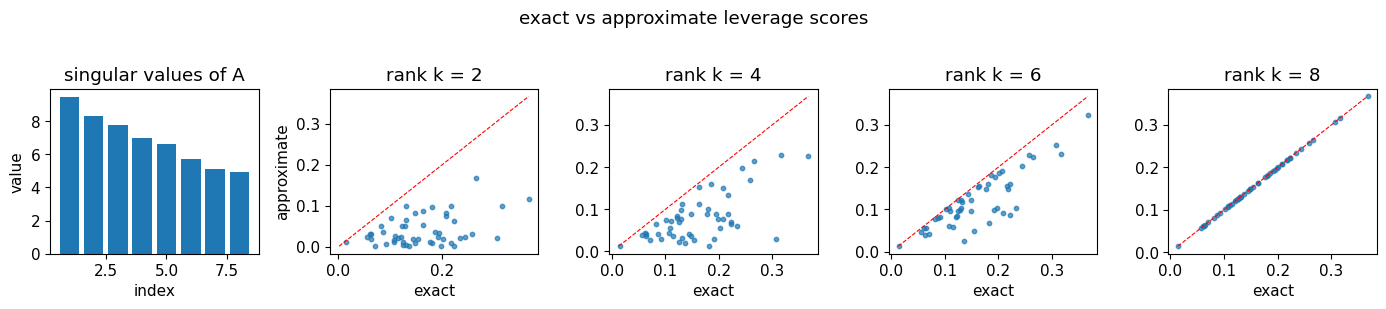

In [ ]:
_, s_A, _ = np.linalg.svd(A, full_matrices=False)

fig, axes = plt.subplots(1, 5, figsize=(14, 3))

axes[0].bar(range(1, len(s_A) + 1), s_A)
axes[0].set_title('singular values of A')
axes[0].set_xlabel('index')
axes[0].set_ylabel('value')

for i, k in enumerate([2, 4, 6, 8]):
    lev_k = leverage_scores_approx(A, k=k)
    ax = axes[i + 1]
    ax.scatter(lev_exact, lev_k, s=10, alpha=0.7)
    lo = min(lev_exact.min(), lev_k.min())
    hi = max(lev_exact.max(), lev_k.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=0.8)
    ax.set_title(f'rank k = {k}')
    ax.set_xlabel('exact')
    if i == 0:
        ax.set_ylabel('approximate')

plt.suptitle('exact vs approximate leverage scores', y=1.02)
plt.tight_layout()
plt.show()

***
## Section 3. Coreset Selection

A **coreset** for a matrix $A \in \mathbb{R}^{n \times d}$ is a small subset of
rows $S \subseteq [n]$ with $|S| = m \ll n$ such that $A_S$ (the submatrix of
rows in $S$) preserves important geometric properties of $A$.

### Leverage score sampling

Sample row $i$ with probability
$$p_i = \frac{h_{ii}}{\sum_j h_{jj}} = \frac{h_{ii}}{d}$$

Rows with high leverage scores are structurally important: omitting them destroys
the low-rank approximation. Rows with low leverage scores are near the centroid of
the row space and can be safely sub-sampled.

### Greedy k-center

Start with one random point. At each step, add the point that is furthest from
the current selected set. This is the greedy 2-approximation to the k-center
problem: the resulting diameter is at most twice optimal.

### Random sampling

Select $m$ rows uniformly at random. This is the baseline. It treats every row
as equally important regardless of its position in the row space.

In [33]:
def leverage_sampler(A, m, k=None, seed=0):
    """
    Select m rows by leverage score sampling.
    k: SVD rank for approximation. If None, use exact SVD.
    """
    # TODO
    # 1. Compute leverage scores (use leverage_scores_approx if k is given,
    #    leverage_scores_exact otherwise).
    # 2. Normalize to a probability distribution: p_i = lev_i / sum(lev).
    # 3. Sample m indices without replacement according to p using rng.choice.
    leverage_scores = None
    if k is not None:
        leverage_scores = leverage_scores_approx(A,k)
    else:
        leverage_scores = leverage_scores_exact(A)
    
    p_matrix = leverage_scores / np.sum(leverage_scores)
    
    return rng.choice(A.shape[0],size=m,replace=False,p=p_matrix)      
        
    # raise NotImplementedError


def random_sampler(A, m, seed=0):
    """Select m rows uniformly at random."""
    rng = np.random.default_rng(seed)
    return rng.choice(len(A), size=m, replace=False)


def kcenter_greedy(A, m, seed=0):
    """
    Greedy k-center: iteratively select the row furthest from the current set.
    Uses the identity ||a-b||^2 = ||a||^2 - 2 a.b + ||b||^2 for efficiency.
    """
    # TODO
    # 1. Pick a random starting row (use rng.integers(len(A))).
    # 2. Compute squared distances from all rows to the starting row.
    #    Use the identity above: precompute row_norms_sq = sum(A**2, axis=1),
    #    then dist2 = row_norms_sq - 2*(A @ A[idx]) + row_norms_sq[idx].
    # 3. At each iteration: select argmax of min_dists, add to selected,
    #    update min_dists = minimum(min_dists, dist2_to_new_point).
    #    Mark selected indices so they are not selected again.
    first = rng.integers(len(A))

    row_norms_sq = np.sum(A**2, axis=1)
    min_dists = row_norms_sq - 2*(A @ A[first]) + row_norms_sq[first]

    selected = [first]

    for _ in range(1, m):
        idx = np.argmax(min_dists)
        selected.append(idx)

        dist2 = row_norms_sq - 2*(A @ A[idx]) + row_norms_sq[idx]
        min_dists = np.minimum(min_dists, dist2)

    return np.array(selected)
    # raise NotImplementedError

fraction of outlier rows selected:
  leverage : 0.20
  random   : 0.40
  k-center : 1.00


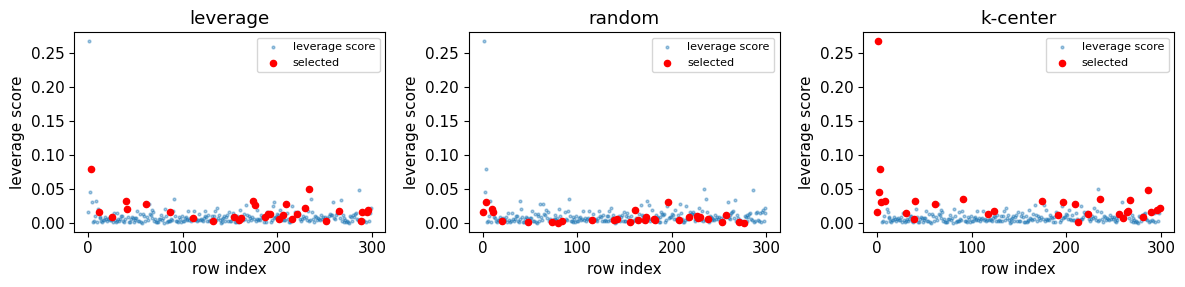

In [34]:
# synthetic example: low-rank matrix with a few extreme rows
rng2 = np.random.default_rng(1)
n_syn, d_syn = 300, 6
U_true = rng2.standard_normal((n_syn, 3))
V_true = rng2.standard_normal((3, d_syn))
A_syn = U_true @ V_true + 0.05 * rng2.standard_normal((n_syn, d_syn))
# add 5 high-leverage outlier rows
A_syn[:5] = 4.0 * rng2.standard_normal((5, d_syn))

lev_syn = leverage_scores_approx(A_syn, k=3)
m_syn = 30
idx_lev = leverage_sampler(A_syn, m_syn, k=3, seed=0)
idx_rnd = random_sampler(A_syn, m_syn, seed=0)
idx_kc  = kcenter_greedy(A_syn, m_syn, seed=0)

def frac_outliers_selected(indices, n_outliers=5):
    return np.sum(indices < n_outliers) / n_outliers

print('fraction of outlier rows selected:')
print(f'  leverage : {frac_outliers_selected(idx_lev):.2f}')
print(f'  random   : {frac_outliers_selected(idx_rnd):.2f}')
print(f'  k-center : {frac_outliers_selected(idx_kc):.2f}')

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, idx, name in zip(axes,
                          [idx_lev, idx_rnd, idx_kc],
                          ['leverage', 'random', 'k-center']):
    ax.scatter(range(n_syn), lev_syn, s=4, alpha=0.4, label='leverage score')
    ax.scatter(idx, lev_syn[idx], s=20, color='red', zorder=3, label='selected')
    ax.set_title(name)
    ax.set_xlabel('row index')
    ax.set_ylabel('leverage score')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Random Sampling

Advantages:

*    1 - Simple and fast to implement 
*    2 - No need to compute any data-dependent scores
*    3 - Works well as a baseline method
*    4 - Computationally very cheap


### Leverage Score Sampling

Advantages:

*    1 - Selects more influential data points (high leverage)
*    2 - Improves quality of subset for linear regression problems
*    3 - Captures important geometric structure of data
*    4 - Better than random sampling for least squares approximation
*    5 - Can be efficiently approximated using randomized SVD for large datasets

### k-Center Greedy Sampling

Advantages:

*    1 - Ensures high diversity among selected points
*    2 - Covers the feature space evenly (good geometric coverage)
*    3 - Useful for reducing redundancy in dataset
*    4 - Strong performance for clustering and core-set selection
*    5 - Deterministic greedy strategy (less variance than random methods)




***
## Section 4. The Memory Bank as a Matrix

The memory bank $M \in \mathbb{R}^{62720 \times 768}$ has one row per patch.
Before selecting a coreset, it is worth understanding the geometry of this matrix.

If the singular values of $M$ decay rapidly, the data lives near a low-dimensional
subspace and a small number of directions captures most of the variance.
In that case, approximate leverage scores computed from a rank-$k$ SVD with small
$k$ are already accurate, and the coreset sampler needs only this truncated basis.

The leverage score heatmap maps $h_{ii}$ back to the spatial position of each patch.
Regions with high leverage scores are those whose feature vectors lie far from the
centroid of the column space. These are the patches the coreset must preserve.

effective rank (threshold 1% of sigma_1): 128
variance explained by top 64 components: 98.5%


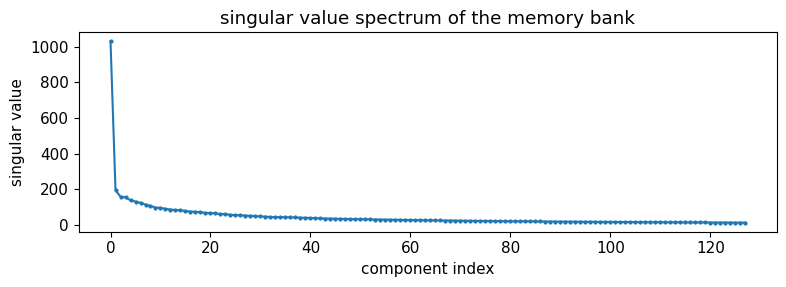

In [35]:
# randomized SVD: much faster than full SVD for large matrices
k_analysis = 128
U_mb, s_mb, Vt_mb = randomized_svd(memory_bank, n_components=k_analysis, random_state=0)

effective_rank = int(np.sum(s_mb > 0.01 * s_mb[0]))
var_64 = float(np.sum(s_mb[:64] ** 2) / np.sum(s_mb ** 2))

print(f'effective rank (threshold 1% of sigma_1): {effective_rank}')
print(f'variance explained by top 64 components: {var_64:.1%}')

plt.figure(figsize=(8, 3))
plt.plot(s_mb, marker='.', ms=4)
plt.xlabel('component index')
plt.ylabel('singular value')
plt.title('singular value spectrum of the memory bank')
plt.tight_layout()
plt.show()

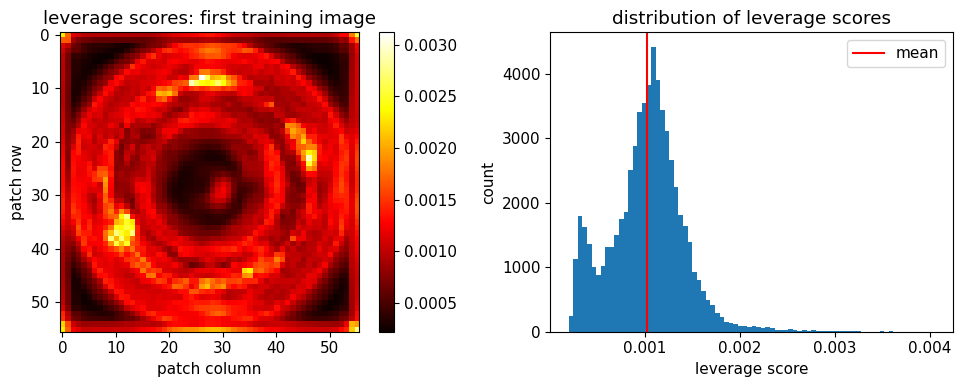

mean leverage score: 0.001020  (= k/n = 64/62720 = 0.001020)


In [36]:
k_lev = 64
lev_mb = leverage_scores_approx(memory_bank, k=k_lev)
prob_cache = lev_mb / lev_mb.sum()   # sampling distribution; reused in Section 5

# patches 0:3136 come from the first training image, laid out as a 56x56 grid
n_patches_per_image = 56 * 56
lev_grid = lev_mb[:n_patches_per_image].reshape(56, 56)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im = axes[0].imshow(lev_grid, cmap='hot')
plt.colorbar(im, ax=axes[0])
axes[0].set_title('leverage scores: first training image')
axes[0].set_xlabel('patch column')
axes[0].set_ylabel('patch row')

axes[1].hist(lev_mb, bins=80, edgecolor='none')
axes[1].axvline(lev_mb.mean(), color='red', lw=1.5, label='mean')
axes[1].set_xlabel('leverage score')
axes[1].set_ylabel('count')
axes[1].set_title('distribution of leverage scores')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f'mean leverage score: {lev_mb.mean():.6f}  (= k/n = {k_lev}/{len(memory_bank)} = {k_lev/len(memory_bank):.6f})')

### summary of what we gained about the diffrence of leverage score and singular value(SVD)

* SVD is used for feature compression and low-rank approximation, while leverage score sampling is used for selecting the most informative data points. Together, they enable efficient processing of large-scale datasets by reducing both dimensionality and dataset size.

***
## Section 4.1  Visualising the Bottle Features

The patch features are 768-dimensional vectors and cannot be viewed directly.
Two complementary views make the geometry concrete.

**PCA pseudo-color.**
Project each 768-dimensional patch vector onto the first three principal
components of the memory bank. Map those three coordinates to RGB channels.
The result is a false-color image where color encodes the dominant directions
of variation in feature space. Patches that look similar in feature space
will share similar colors.

**Leverage heatmap.**
The leverage score $h_{ii}$ measures how much patch $i$ contributes to
spanning the rank-$k$ subspace. Mapping scores back to the 56 x 56 spatial
grid shows which regions of a bottle image are geometrically most distinctive.

After the nearest-neighbor scoring function is defined in Section 5, a third
visualization shows, for each defect type, how well the 10% leverage coreset
separates anomalous patches from background patches in terms of distance.

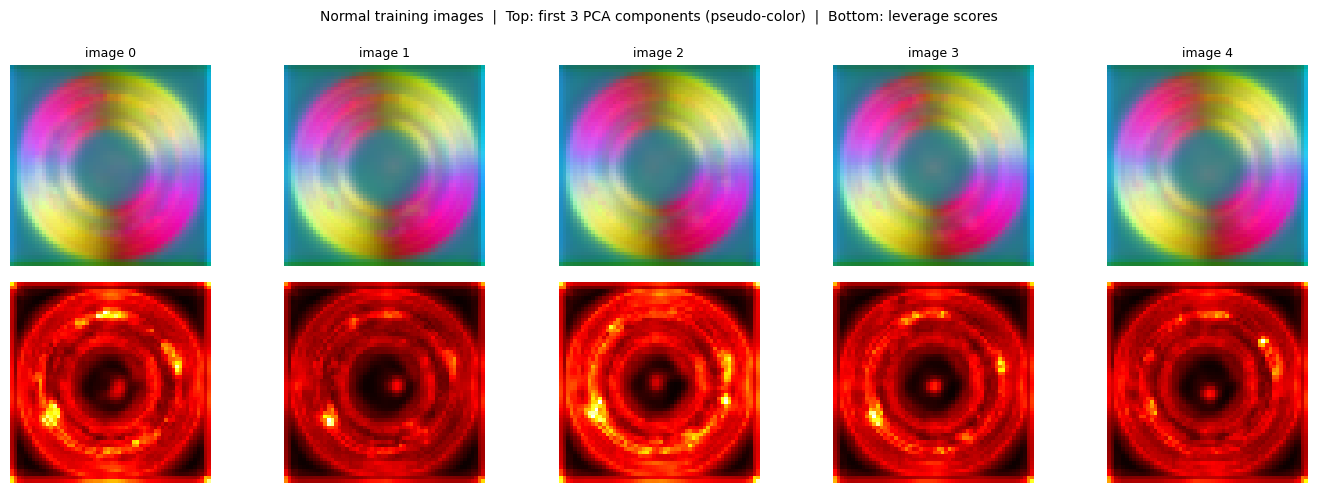

In [42]:
from sklearn.decomposition import PCA

n_show = 5
pca3 = PCA(n_components=3, random_state=0)
pca3.fit(memory_bank)                            # fit on full bank

fig, axes = plt.subplots(2, n_show, figsize=(14, 5))
for i in range(n_show):
    feats = memory_bank[i * n_patches_per_image : (i + 1) * n_patches_per_image]

    # pseudo-color: project to 3 dims, normalise to [0, 1]
    rgb = pca3.transform(feats)                  # (3136, 3)
    rgb = rgb - rgb.min(axis=0)
    rgb = rgb / (rgb.max(axis=0) + 1e-8)
    axes[0, i].imshow(rgb.reshape(56, 56, 3))
    axes[0, i].set_title(f'image {i}', fontsize=9)
    axes[0, i].axis('off')

    # leverage heatmap
    lev_i = lev_mb[i * n_patches_per_image : (i + 1) * n_patches_per_image]
    axes[1, i].imshow(lev_i.reshape(56, 56), cmap='hot')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('PCA', fontsize=9)
axes[1, 0].set_ylabel('leverage', fontsize=9)
plt.suptitle(
    'Normal training images  |  Top: first 3 PCA components (pseudo-color)'
    '  |  Bottom: leverage scores',
    fontsize=10,
)
plt.tight_layout()
plt.show()

***
## Section 5. Anomaly Detection

At test time, a patch feature vector $q \in \mathbb{R}^{768}$ is scored by
its distance to the nearest neighbor in the coreset $C$:

$$s(q) = \min_{c \in C} \|q - c\|_2$$

A patch is declared anomalous if $s(q)$ exceeds a threshold.
The image-level score is not used here; instead, the quality of the coreset
is measured by the **pixel-level AUROC**: the area under the ROC curve where
each point is a patch, its score is $s(q)$, and its label is 1 (defect) or 0
(background), as determined by the ground truth mask.

A perfect coreset preserves the nearest-neighbor structure of the full memory bank.
The goal is to achieve high AUROC at small coreset size.

In [47]:
def nn_distance(queries, bank, bank_norms_sq=None, batch_size=512):
    """
    For each row of queries, return the L2 distance to its nearest row in bank.
    queries       : (Q, D)
    bank          : (M, D)
    bank_norms_sq : (M,) precomputed squared row norms (optional)
    Returns       : (Q,) array of distances
    """
    # TODO
    # Use the identity  ||q - b||^2 = ||q||^2 - 2 q b^T + ||b||^2
    # to compute pairwise squared distances without any Python loop over rows.
    # Process queries in batches of batch_size to avoid building a (Q x M) matrix
    # in one shot when M is large.
    # If bank_norms_sq is None, compute it inside this function.
    
    Q, D = queries.shape
    M = bank.shape[0]

    # precompute ||b||^2 if not given
    if bank_norms_sq is None:
        bank_norms_sq = np.sum(bank**2, axis=1)

    # ||q||^2 for all queries
    query_norms_sq = np.sum(queries**2, axis=1)

    # output
    min_dists = np.empty(Q)

    for i in range(0, Q, batch_size):
        j = min(i + batch_size, Q)
        q_batch = queries[i:j]

        # ||q||^2 (batch)
        q_norm_sq = query_norms_sq[i:j].reshape(-1, 1)

        # q b^T
        cross_term = q_batch @ bank.T  # (B, M)

        # squared distances: ||q||^2 - 2 q.b + ||b||^2
        dists_sq = q_norm_sq - 2 * cross_term + bank_norms_sq

        # nearest neighbor
        min_dists[i:j] = np.min(dists_sq, axis=1)

    return min_dists
    # raise NotImplementedError


def compute_auroc(coreset, anomaly_dir):
    """
    Compute pixel-level AUROC over all test images.
    Each anomaly image has two files: *_anomaly.npy (label=1) and *_normal.npy (label=0).
    """
    all_scores = []
    all_labels = []

    fnames = sorted(os.listdir(anomaly_dir))
    images = {}
    for fname in fnames:
        base, tag = fname.rsplit('_', 1)
        tag = tag.replace('.npy', '')
        if base not in images:
            images[base] = {}
        images[base][tag] = fname

    for base, files in images.items():
        pa = np.load(os.path.join(anomaly_dir, files['anomaly'])).astype(np.float32)
        pn = np.load(os.path.join(anomaly_dir, files['normal'])).astype(np.float32)
        patches = np.concatenate([pa, pn], axis=0)
        labels  = np.concatenate([np.ones(len(pa)), np.zeros(len(pn))])
        # TODO: compute nn_distance from patches to coreset and append scores and labels
        scores = nn_distance(patches, coreset)
        all_scores.append(scores)
        all_labels.append(labels)
        # raise NotImplementedError

    return roc_auc_score(np.concatenate(all_labels), np.concatenate(all_scores))

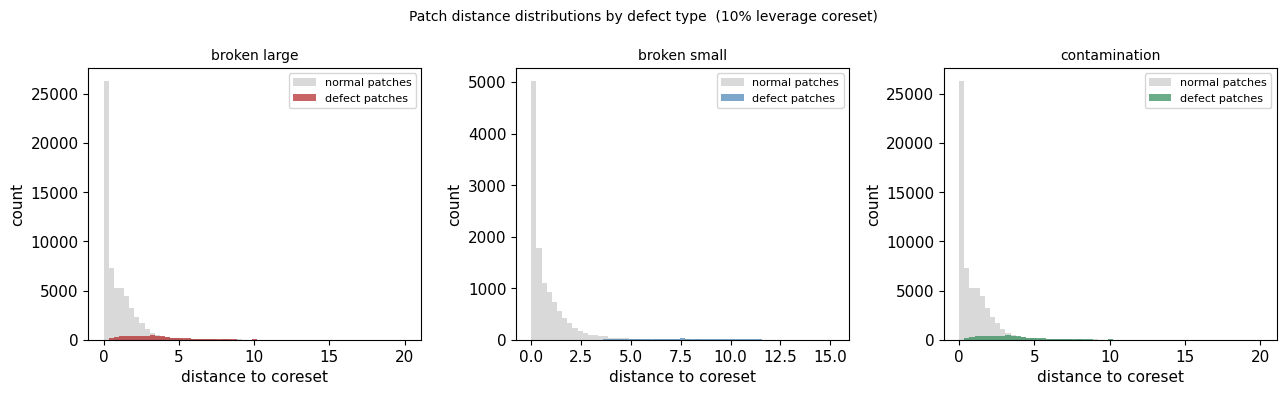

In [104]:
# build a 10% leverage coreset for visualisation
m_vis = int(len(memory_bank) * 0.10)
rng_vis = np.random.default_rng(0)
idx_vis = rng_vis.choice(len(memory_bank), size=m_vis, replace=False, p=prob_cache)
coreset_vis = memory_bank[idx_vis]
b2_vis = np.sum(coreset_vis ** 2, axis=1)

defect_types   = ['broken_large', 'broken_small', 'contamination']
defect_colors  = ['firebrick', 'steelblue', 'seagreen']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, dtype, color in zip(axes, defect_types, defect_colors):
    a_scores, n_scores = [], []
    for fname in sorted(os.listdir(anomaly_dir)):
        # print(fname)
        if dtype not in fname:
            continue
        patches = np.load(os.path.join(anomaly_dir, fname)).astype(np.float32)
        scores  = nn_distance(patches, coreset_vis, bank_norms_sq=b2_vis)
        if fname.endswith('_anomaly.npy'):
            a_scores.append(scores)
        else:
            n_scores.append(scores)

    # print('ascore',a_scores)
    if a_scores:
        a_all = np.concatenate(a_scores)
    if n_scores:
        n_all = np.concatenate(n_scores)
    hi = max(a_all.max(), n_all.max())
    bins  = np.linspace(0, hi, 60)

    ax.hist(n_all, bins=bins, alpha=0.6, color='silver', label='normal patches')
    ax.hist(a_all, bins=bins, alpha=0.7, color=color,  label='defect patches')
    ax.set_title(dtype.replace('_', ' '), fontsize=10)
    ax.set_xlabel('distance to coreset')
    ax.set_ylabel('count')
    ax.legend(fontsize=8)

plt.suptitle(
    'Patch distance distributions by defect type  (10% leverage coreset)',
    fontsize=10,
)
plt.tight_layout()
plt.show()


In [105]:
# percentages to test; k-center is excluded from 20% to keep runtime reasonable
pcts_all     = [0.01, 0.05, 0.10, 0.20]
pcts_kcenter = [0.01, 0.05, 0.10]

results = {'leverage': [], 'random': [], 'kcenter': []}

# prob_cache was computed in Section 4 (leverage scores of the memory bank)
# reuse it here without recomputing the SVD
rng_s = np.random.default_rng(0)

for pct in pcts_all:
    m = max(1, int(len(memory_bank) * pct))
    print(f'coreset {pct:.0%} ({m})', end='')

    idx = rng_s.choice(len(memory_bank), size=m, replace=False, p=prob_cache)
    results['leverage'].append(compute_auroc(memory_bank[idx], anomaly_dir))
    print(f'  leverage: {results["leverage"][-1]:.4f}', end='')

    idx = random_sampler(memory_bank, m, seed=0)
    results['random'].append(compute_auroc(memory_bank[idx], anomaly_dir))
    print(f'  random: {results["random"][-1]:.4f}')

print('running k-center ...')
for pct in pcts_kcenter:
    m = max(1, int(len(memory_bank) * pct))
    idx = kcenter_greedy(memory_bank, m, seed=0)
    results['kcenter'].append(compute_auroc(memory_bank[idx], anomaly_dir))
    print(f'  k-center {pct:.0%}: {results["kcenter"][-1]:.4f}')

coreset 1% (627)  leverage: 0.8510  random: 0.8280
coreset 5% (3136)  leverage: 0.8976  random: 0.8909
coreset 10% (6272)  leverage: 0.9093  random: 0.9035
coreset 20% (12544)  leverage: 0.9153  random: 0.9118
running k-center ...
  k-center 1%: 0.8854
  k-center 5%: 0.9143
  k-center 10%: 0.9262


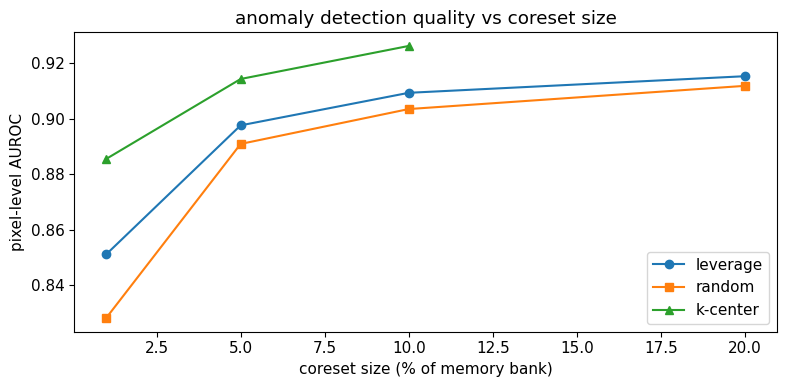

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot([p * 100 for p in pcts_all], results['leverage'],
         marker='o', label='leverage')
plt.plot([p * 100 for p in pcts_all], results['random'],
         marker='s', label='random')
plt.plot([p * 100 for p in pcts_kcenter], results['kcenter'],
         marker='^', label='k-center')
plt.xlabel('coreset size (% of memory bank)')
plt.ylabel('pixel-level AUROC')
plt.title('anomaly detection quality vs coreset size')
plt.legend()
plt.tight_layout()
plt.show()

***
## Section 6. Analysis

Answer each question in a markdown cell below it.

**Question 1.**
The mean leverage score satisfies $\bar{h} = k/n$ exactly, where $k$ is the SVD rank
and $n$ is the number of rows. Prove this from the definition $h_{ii} = \|u_i\|_2^2$
and the orthonormality of $U$.




**Question 2.**
In the comparison plot, leverage score sampling and k-center greedy typically
outperform random sampling at small coreset sizes. Using the singular value spectrum
from Section 4, explain geometrically why uniform random sampling is disadvantaged
when the data lies near a low-dimensional subspace.

**Question 3.**
The leverage score sampler uses rank $k = 64$ to approximate leverage scores.
From the variance-explained result in Section 4, argue whether $k = 64$ is
a conservative or aggressive choice, and what happens to detection quality
if you reduce $k$ to 16.

**Question 4.**
The leverage scores were computed from the training normal patches only.
Suppose you observed a batch of 100 test patches $Q \in \mathbb{R}^{100 \times 768}$.
Describe, in terms of a matrix operation, how you would update the leverage scores
of the memory bank to account for the directions spanned by $Q$.
You do not need to implement this.

# Section 6. Analysis

***

## Question 1

The mean leverage score satisfies:

$$
\bar{h} = \frac{k}{n}
$$

We start from the definition of leverage score:

$$
h_{ii} = \|u_i\|_2^2
$$

where \(u_i\) is the \(i\)-th row of \(U\).

Now sum all leverage scores:

$$
\sum_{i=1}^{n} h_{ii}
=
\sum_{i=1}^{n} \|u_i\|_2^2
$$

The right-hand side is exactly the squared Frobenius norm of \(U\):

$$
\sum_{i=1}^{n} \|u_i\|_2^2
=
\|U\|_F^2
$$

Since \(U\) has orthonormal columns:

$$
U^T U = I_k
$$

Therefore:

$$
\|U\|_F^2
=
\mathrm{trace}(U^T U)
=
\mathrm{trace}(I_k)
=
k
$$

So:

$$
\sum_{i=1}^{n} h_{ii} = k
$$

Dividing by \(n\), we get:

$$
\bar{h}
=
\frac{1}{n}
\sum_{i=1}^{n} h_{ii}
=
\frac{k}{n}
$$

Therefore, the mean leverage score is exactly:

$$
\bar{h} = \frac{k}{n}
$$

***

## Question 2

Uniform random sampling is disadvantaged when the data lies near a low-dimensional subspace.

From the singular value spectrum in Section 4, we observed that most of the variance is concentrated in the first few singular directions. This means that the data does not fully occupy the original high-dimensional space. Instead, most points lie near a much lower-dimensional subspace.

Geometrically, many rows of the memory bank are redundant because they represent similar directions in feature space. However, a small number of points may be important because they represent rare or extreme directions of the subspace.

Uniform random sampling treats all rows equally. Therefore, at small coreset sizes, it may select many redundant points and miss important high-leverage points.

Leverage score sampling is better because it gives higher probability to points that contribute more to the important subspace directions. k-center greedy is also better because it tries to cover the geometry of the data by selecting diverse points.

Therefore, when the data lies near a low-dimensional subspace, uniform random sampling is weaker because it does not use the geometry or importance of the data points.

***

## Question 3

From Section 4, the top 64 singular components explain about 98.5% of the variance.

This means that \(k = 64\) captures almost all of the important structure of the memory bank. Therefore, using \(k = 64\) for approximate leverage scores is a conservative and reasonable choice.

It is conservative because we keep enough components to preserve most of the meaningful directions in the data. We are not only keeping a very small number of components.

If we reduce \(k\) to 16, the approximation becomes more aggressive. In that case, fewer singular directions are preserved. Some important but lower-variance directions may be ignored.

As a result, the leverage scores become less accurate, the selected coreset may be less representative, and the nearest-neighbor structure may not be preserved well.

This can reduce anomaly detection quality because defective patches may no longer be clearly separated from normal patches.

So, \(k = 64\) is a stable choice, while \(k = 16\) may be too aggressive and can decrease AUROC.

***

## Question 4

The leverage scores were computed only from the normal training memory bank.

Suppose we observe a batch of test patches:

$$
Q \in \mathbb{R}^{100 \times 768}
$$

To account for the directions spanned by \(Q\), we can augment the memory bank matrix \(A\) by adding \(Q\) as new rows:

$$
A_{\mathrm{aug}}
=
\begin{bmatrix}
A \\
Q
\end{bmatrix}
$$

Then we compute the SVD of the augmented matrix:

$$
A_{\mathrm{aug}} = U_{\mathrm{aug}} \Sigma V^T
$$

The updated leverage score of row \(i\) is:

$$
h_{ii}^{\mathrm{new}}
=
\|u_i^{\mathrm{aug}}\|_2^2
$$

For the original memory bank, we take only the rows of \(U_{\mathrm{aug}}\) that correspond to the original rows of \(A\).

Equivalently, we can describe this update using the projection matrix:

$$
H_{\mathrm{new}}
=
A_{\mathrm{aug}}
\left(
A_{\mathrm{aug}}^T A_{\mathrm{aug}}
\right)^{-1}
A_{\mathrm{aug}}^T
$$

The updated leverage scores are the diagonal entries of \(H_{\mathrm{new}}\).

This update changes the leverage scores because adding \(Q\) changes the subspace directions used to represent the data.